In [43]:
from dataset_gbm import GBMGenerativeDataset, estimate_parameters, reverse_log_return
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [44]:
# !python generate.py --seeds=0-9999 \
#                     --network=out_train_ts/00040-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-DZ3U5/network-snapshot-005001.pkl \
#                     --outdir=out_train_ts/00040-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-DZ3U5/generated_samples \
#                     --batch=64

In [45]:
generated_filepath = 'out_train_ts/00040-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-DZ3U5/generated_samples/generated_paths.npy'

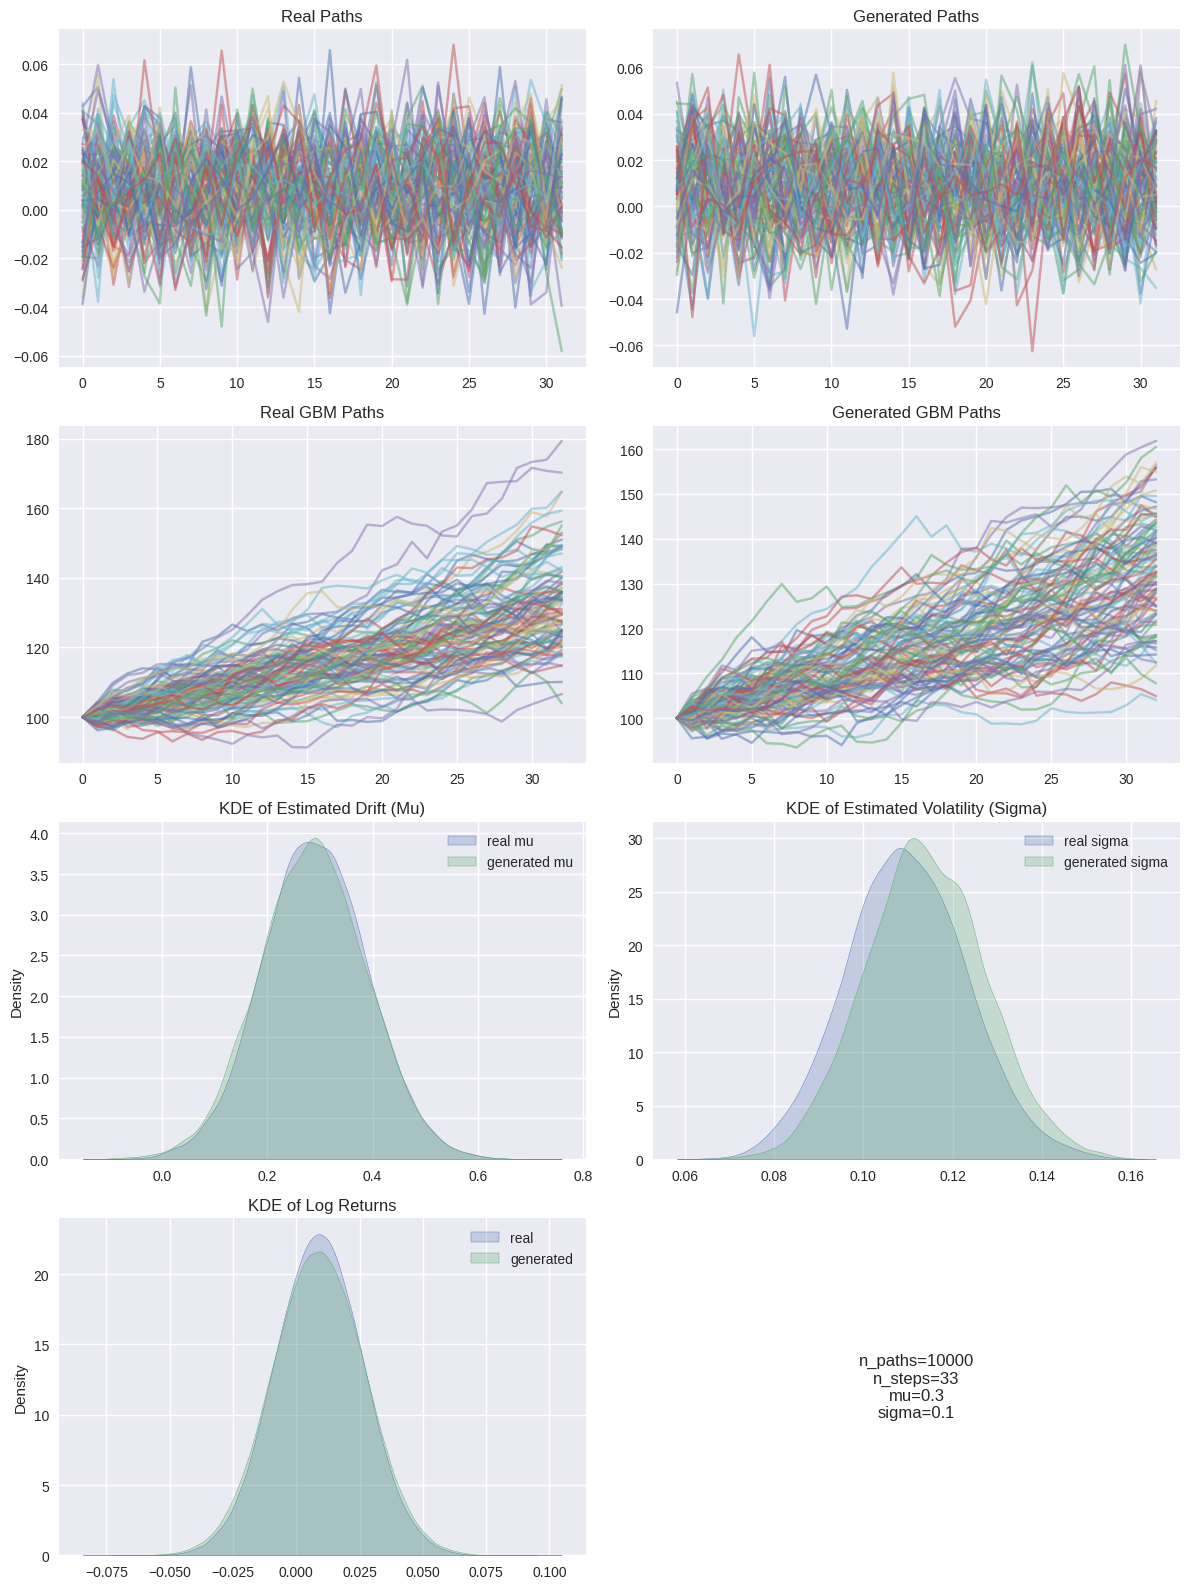

In [46]:
# Parameters
n_paths = 10000
n_steps = 33
mu = 0.3
sigma = 0.1
GENERATE_LOG_RETURNS = True

# Generate dataset
dataset = GBMGenerativeDataset(n_paths=n_paths, n_steps=n_steps, mu=mu, sigma=sigma, return_log_returns=GENERATE_LOG_RETURNS)
real = dataset.paths.squeeze()
generated = np.load(generated_filepath)
generated_unnorm = generated * np.mean(real)

# Reverse log returns to obtain price paths
real_gbm = reverse_log_return(real, s0=100)
generated_gbm = reverse_log_return(generated_unnorm, s0=100)

# Estimate parameters
mu_real, sigma_real = estimate_parameters(real_gbm, dataset.dt)
mu_gen, sigma_gen = estimate_parameters(generated_gbm, dataset.dt)

# Create figure with subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# Plot 1: Real Paths
for path in real[:100]:
    axes[0, 0].plot(path, alpha=0.5)
axes[0, 0].set_title("Real Paths")

# Plot 2: Generated Paths
for path in generated_unnorm[:100]:
    axes[0, 1].plot(path, alpha=0.5)
axes[0, 1].set_title("Generated Paths")

# Plot 3: Real GBM Paths
for path in real_gbm[:100]:
    axes[1, 0].plot(path, alpha=0.5)
axes[1, 0].set_title("Real GBM Paths")

# Plot 4: Generated GBM Paths
for path in generated_gbm[:100]:
    axes[1, 1].plot(path, alpha=0.5)
axes[1, 1].set_title("Generated GBM Paths")

# Plot 5: KDE of Estimated Drift (Mu)
sns.kdeplot(mu_real, label='real mu', fill=True, ax=axes[2, 0])
sns.kdeplot(mu_gen, label='generated mu', fill=True, ax=axes[2, 0])
axes[2, 0].legend()
axes[2, 0].set_title("KDE of Estimated Drift (Mu)")

# Plot 6: KDE of Estimated Volatility (Sigma)
sns.kdeplot(sigma_real, label='real sigma', fill=True, ax=axes[2, 1])
sns.kdeplot(sigma_gen, label='generated sigma', fill=True, ax=axes[2, 1])
axes[2, 1].legend()
axes[2, 1].set_title("KDE of Estimated Volatility (Sigma)")

# Plot 7: KDE of Log Returns
sns.kdeplot(real.flatten(), label='real', fill=True, ax=axes[3, 0])
sns.kdeplot(generated_unnorm.flatten(), label='generated', fill=True, ax=axes[3, 0])
axes[3, 0].legend()
axes[3, 0].set_title("KDE of Log Returns")

# Add parameters as text in the figure
params_text = f"n_paths={n_paths}\nn_steps={n_steps}\nmu={mu}\nsigma={sigma}"
axes[3, 1].text(0.5, 0.5, params_text, fontsize=12, ha='center', va='center', bbox={"facecolor": "white", "alpha": 0.5, "pad": 5})
axes[3, 1].set_axis_off()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()
